## MACHINE LEARNING ASSIGNMENT 
### Student Number: 3547228

# Urban Infrastructure Failure Prediction


### Step 0 – Install & Import Libraries

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier

# Metrics
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix


### STEP 1 – LOAD AND EXPLORE THE DATASET



In [43]:
# Load csv dataset
data = pd.read_csv('urbandata.csv')

In [44]:
# Dataset shape
data.shape

(456, 12)

In [45]:
# Column data types
data.dtypes

inspector_id               int64
material_flexibility     float64
structural_mass_ratio    float64
recent_precipitation     float64
infrastructure_age       float64
surface_debris           float64
vibration_exposure       float64
asset_density            float64
inspection_season         object
inspection_window         object
moisture_stress          float64
failure                    int64
dtype: object

In [46]:
# first 5 rows
data.head()

,inspector_id,material_flexibility,structural_mass_ratio,recent_precipitation,infrastructure_age,surface_debris,vibration_exposure,asset_density,inspection_season,inspection_window,moisture_stress,failure
0,5,31.762605,12.891996,4.711064,71.480592,9.429642,5.177088,2.9944,summer,afternoon,0.06,1
1,7,30.770158,11.835563,3.315888,60.300892,8.655641,4.927622,2.6808,spring,morning,0.01,0
2,6,31.591296,11.738267,2.425562,56.367965,9.017137,4.910945,2.5294,autumn,night,0.02,0
3,5,30.834649,11.622881,2.164486,53.135138,8.864650,4.949554,2.4810,autumn,afternoon,0.02,1
4,2,33.315981,12.616065,4.557082,77.482269,9.549344,5.047689,3.0460,summer,morning,0.07,1


In [47]:
# Check data information for encoding decision
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456 entries, 0 to 455
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   inspector_id           456 non-null    int64  
 1   material_flexibility   456 non-null    float64
 2   structural_mass_ratio  455 non-null    float64
 3   recent_precipitation   454 non-null    float64
 4   infrastructure_age     452 non-null    float64
 5   surface_debris         456 non-null    float64
 6   vibration_exposure     455 non-null    float64
 7   asset_density          456 non-null    float64
 8   inspection_season      456 non-null    object 
 9   inspection_window      456 non-null    object 
 10  moisture_stress        453 non-null    float64
 11  failure                456 non-null    int64  
dtypes: float64(8), int64(2), object(2)
memory usage: 42.9+ KB


In [48]:
# Summary statistics for all numeric columns
data.describe()

,inspector_id,material_flexibility,structural_mass_ratio,recent_precipitation,infrastructure_age,surface_debris,vibration_exposure,asset_density,moisture_stress,failure
count,456.000000,456.000000,455.000000,454.000000,452.000000,456.000000,455.000000,456.000000,453.000000,456.000000
mean,5.730263,32.592037,12.089241,3.110861,68.532487,9.271769,4.962680,2.654610,0.037108,0.368421
std,2.921622,4.738187,0.591701,1.365354,14.490899,0.790136,0.080109,0.268216,0.051781,0.482906
min,1.000000,24.924765,11.506094,0.000000,41.087602,7.426926,4.743956,2.200000,0.000000,0.000000
25%,3.000000,30.496861,11.672524,2.140594,58.594494,8.744313,4.911817,2.451540,0.010000,0.000000
50%,6.000000,31.902116,11.863909,2.925396,64.789151,9.125281,4.960576,2.595360,0.020000,0.000000
75%,8.000000,34.026756,12.332858,4.314350,76.739522,9.771380,5.010956,2.845200,0.040000,1.000000
max,11.000000,91.157913,14.823489,6.089045,125.949551,11.719278,5.249006,3.364000,0.480000,1.000000


In [49]:

# Check Class Balance (Target Variable)

print("Target Variable Distribution:\n")

# Count values
class_counts = data['failure'].value_counts()
print(class_counts)

# Calculate counts
no_failure_count = (data['failure'] == 0).sum()
failure_count = (data['failure'] == 1).sum()

# Calculate percentages
no_failure_pct = (data['failure'] == 0).mean() * 100
failure_pct = (data['failure'] == 1).mean() * 100

# Display results
print("\nDetailed Breakdown:")
print(f"No Failure (0): {no_failure_count} rows ({no_failure_pct:.1f}%)")
print(f"Failure    (1): {failure_count} rows ({failure_pct:.1f}%)")


print("\nInterpretation:")
print("The dataset shows a moderate class imbalance.")
print("Accuracy alone may be misleading.")
print("Due to moderate class imbalance, ROC-AUC is a more informative evaluation metric than accuracy.")

Target Variable Distribution:

failure
0    288
1    168
Name: count, dtype: int64

Detailed Breakdown:
No Failure (0): 288 rows (63.2%)
Failure    (1): 168 rows (36.8%)

Interpretation:
The dataset shows a moderate class imbalance.
Accuracy alone may be misleading.
Due to moderate class imbalance, ROC-AUC is a more informative evaluation metric than accuracy.


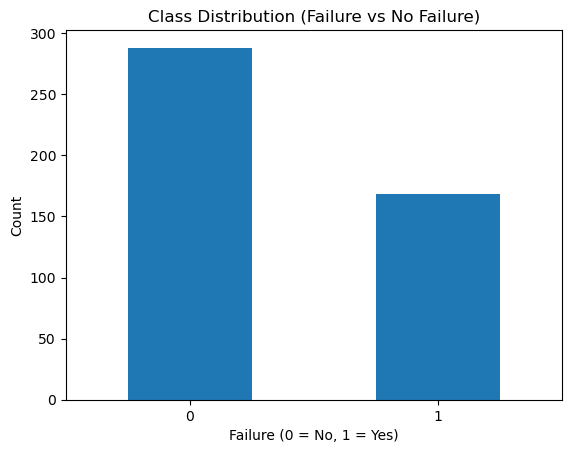

In [50]:
# Visualize Class Distribution

class_counts = data['failure'].value_counts()

plt.figure()
class_counts.plot(kind='bar')

plt.title("Class Distribution (Failure vs No Failure)")
plt.xlabel("Failure (0 = No, 1 = Yes)")
plt.ylabel("Count")

plt.xticks(rotation=0)
plt.show()

In [51]:
# Check for missing values across all columns
print("Missing values per column:")
print(data.isnull().sum())

Missing values per column:
inspector_id             0
material_flexibility     0
structural_mass_ratio    1
recent_precipitation     2
infrastructure_age       4
surface_debris           0
vibration_exposure       1
asset_density            0
inspection_season        0
inspection_window        0
moisture_stress          3
failure                  0
dtype: int64


In [52]:
# Check unique values for categorical columns to spot any typo errors
print("Unique inspection_season values:", data['inspection_season'].unique())
print("Unique inspection_window values:", data['inspection_window'].unique())

# ERRORS DETECTED:
#    'sumer'    → should be 'summer'  (typo)
#    'morni7ng' → should be 'morning' (data entry error)

Unique inspection_season values: ['summer' 'spring' 'autumn' 'winter' 'sumer']
Unique inspection_window values: ['afternoon' 'morning' 'night' 'morni7ng']


 ### STEP 2 – DATA CLEANING

In [53]:
# The following data quality issues were detected during EDA:

# 1. `material_flexibility` has 2 extreme outlier values (>50) vs. a normal range of ~25–45. These are likely recording errors.
# 2. Typos in categorical columns: 'sumer', 'morni7ng'
# 3. Missing values (NaN) in 5 numeric columns

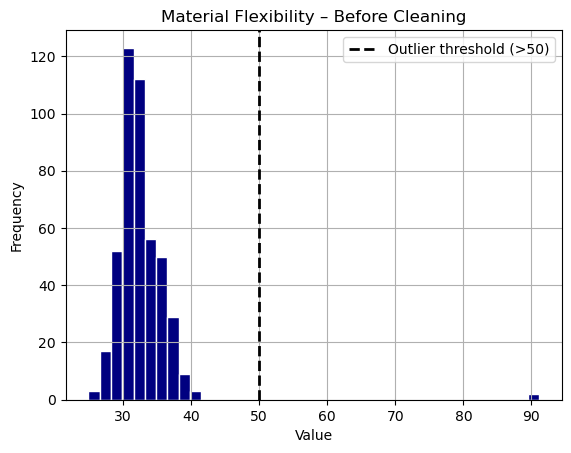

In [54]:
# Visualize the outlier BEFORE cleaning 
# Histogram before cleaning

plt.figure()
data['material_flexibility'].hist(
    bins=40,
    color='navy',
    edgecolor='white'
)

plt.axvline(50, color='black', linestyle='--', linewidth=2,
            label='Outlier threshold (>50)')

plt.title('Material Flexibility – Before Cleaning')
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.legend()

plt.savefig('my_plot.png', dpi=300, bbox_inches='tight')
plt.show()

In [55]:
print("Outlier count (material_flexibility > 50):", (data['material_flexibility'] > 50).sum())
# Two values sit far above 50 (max = 91.2) while the rest cluster ~25-45.
# These are plausible data entry errors; we cap and impute with the median.

Outlier count (material_flexibility > 50): 2


In [56]:
# Cleaning Operation

In [57]:
data_clean = data.copy()

In [58]:
# [FIX 1] Replace outlier values in material_flexibility with NaN
data_clean.loc[data_clean['material_flexibility'] > 50, 'material_flexibility'] = np.nan

In [59]:
# [FIX 2] Correct categorical typos
data_clean['inspection_season'] = data_clean['inspection_season'].replace({'sumer': 'summer'})
data_clean['inspection_window']  = data_clean['inspection_window'].replace({'morni7ng': 'morning'})

In [60]:
# [FIX 3] Impute all remaining numeric NaN values with the column median
#         Median is preferred over mean because it is robust to skew/outliers.
for col in data_clean.select_dtypes(include=[np.number]).columns:
    data_clean[col] = data_clean[col].fillna(data_clean[col].median())

In [61]:
print("Missing values AFTER cleaning:", data_clean.isnull().sum().sum())
print("Unique inspection_season values after fix:", data_clean['inspection_season'].unique())
print("Unique inspection_window values after fix:",  data_clean['inspection_window'].unique())


Missing values AFTER cleaning: 0
Unique inspection_season values after fix: ['summer' 'spring' 'autumn' 'winter']
Unique inspection_window values after fix: ['afternoon' 'morning' 'night']


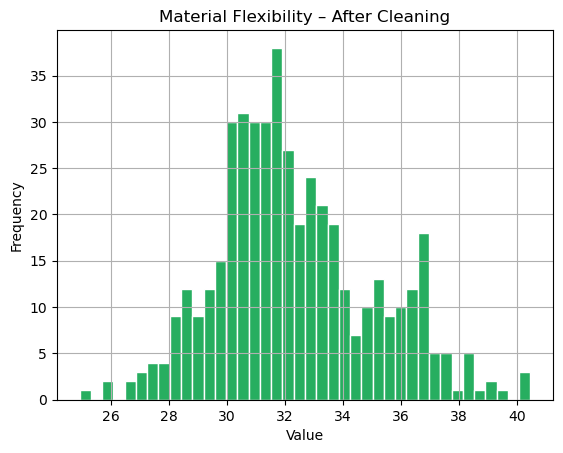

In [62]:
# Visualize material_flexibility AFTER cleaning

plt.figure()
data_clean['material_flexibility'].hist(
    bins=40,
    color='#27ae60',   
    edgecolor='white'
)

plt.title('Material Flexibility – After Cleaning')
plt.xlabel('Value')
plt.ylabel('Frequency')

plt.savefig('my_plot.png', dpi=300, bbox_inches='tight')
plt.show()

## STEP 3 – FEATURE ENGINEERING & ENCODING

In [63]:
# Use the already-cleaned DataFrame (outliers fixed, typos fixed, NaN imputed)
# NOTE: data_clean was fully prepared in Step 2 — we do NOT call dropna() here.
# Calling data.dropna() would (a) discard all cleaning work and
# (b) lose 11 rows by dropping instead of imputing.
data_model = data_clean.copy()

# Drop non-predictive ID column
data_model = data_model.drop(columns=['inspector_id'])

In [64]:
# One-hot encode the two categorical columns (drop_first avoids dummy trap)

data_model = pd.get_dummies(data_model,
                           columns=['inspection_season', 'inspection_window'],
                           drop_first=True)

In [65]:
# Convert any boolean columns produced by get_dummies to integers (0/1)

for col in data_model.select_dtypes('bool').columns:
    data_model[col] = data_model[col].astype(int)

In [66]:
# Separate features (X) and target (y)

X = data_model.drop(columns=['failure'])
y = data_model['failure']

In [67]:
print("Final feature list:")
for i, col in enumerate(X.columns, 1):
    print(f"  {i:2d}. {col}")
print(f"\nFeature matrix shape: {X.shape}")
print(f"Target series shape:  {y.shape}")

Final feature list:
   1. material_flexibility
   2. structural_mass_ratio
   3. recent_precipitation
   4. infrastructure_age
   5. surface_debris
   6. vibration_exposure
   7. asset_density
   8. moisture_stress
   9. inspection_season_spring
  10. inspection_season_summer
  11. inspection_season_winter
  12. inspection_window_morning
  13. inspection_window_night

Feature matrix shape: (456, 13)
Target series shape:  (456,)


## STEP 4 – TRAIN / VALIDATE / TEST SPLIT

In [68]:
# Data Splitting — Stratified 60 / 20 / 20
# stratify=y preserves the 63%/37% class ratio in every split.
# Without stratify, splits may be imbalanced by chance.

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=42, stratify=y_temp)

print(f"Train: {len(X_train)} | Validate: {len(X_val)} | Test: {len(X_test)}")

Train: 273 | Validate: 91 | Test: 92


In [69]:
# Feature Scaling
scaler = StandardScaler()

X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print("Scaling complete. Train mean (approx 0):", X_train_s.mean().round(4))

Scaling complete. Train mean (approx 0): -0.0


## STEP 5 – MODEL TRAINING & HYPERPARAMETER TUNING

In [70]:
# NOTE: The grid search in the next cell (Cell 37) trains each model
# individually across hyperparameter ranges — that is the actual tuning loop.
# The single-config dict below is removed to avoid confusion.

# Hyperparameter grid definitions (used in Cell 37):
#   Logistic Regression : C in [0.01, 0.1, 1.0, 10.0]
#   Decision Tree       : max_depth in [3, 5, 7, 10, None]
#   Neural Network      : hidden_layer_sizes x learning_rate_init (5 combos)

In [71]:

results = []

# Logistic Regression
for C in [0.01, 0.1, 1.0, 10.0]:
    model = LogisticRegression(C=C, max_iter=1000, random_state=42)
    model.fit(X_train_s, y_train)

    val_acc = accuracy_score(y_val, model.predict(X_val_s))
    val_auc = roc_auc_score(y_val, model.predict_proba(X_val_s)[:, 1])

    results.append(['Logistic Regression', f'C={C}', val_acc, val_auc, model, True])


# Decision Tree
for depth in [3, 5, 7, 10, None]:
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(X_train, y_train)

    val_acc = accuracy_score(y_val, model.predict(X_val))
    val_auc = roc_auc_score(y_val, model.predict_proba(X_val)[:, 1])

    results.append(['Decision Tree', f'max_depth={depth}', val_acc, val_auc, model, False])


# Neural Network
configs = [((64,32),0.001), ((128,64),0.001), ((64,64,32),0.001),
           ((64,32),0.01), ((128,64),0.01)]

for layers, lr in configs:
    model = MLPClassifier(hidden_layer_sizes=layers,
                          learning_rate_init=lr,
                          max_iter=500,
                          random_state=42,
                          early_stopping=True,
                          validation_fraction=0.1)
    model.fit(X_train_s, y_train)

    val_acc = accuracy_score(y_val, model.predict(X_val_s))
    val_auc = roc_auc_score(y_val, model.predict_proba(X_val_s)[:, 1])

    results.append(['Neural Network', f'layers={layers}, lr={lr}', val_acc, val_auc, model, True])


# Summary table
res_df = pd.DataFrame(results, columns=['Model','Hyperparameter','Val Accuracy','Val AUC','Model_obj','Scaled'])

summary = res_df.sort_values('Val AUC', ascending=False).reset_index(drop=True)

display(summary[['Model','Hyperparameter','Val Accuracy','Val AUC']])

,Model,Hyperparameter,Val Accuracy,Val AUC
0,Logistic Regression,C=0.01,0.923077,0.977534
1,Logistic Regression,C=0.1,0.923077,0.977534
2,Logistic Regression,C=1.0,0.912088,0.972309
3,Neural Network,"layers=(128, 64), lr=0.01",0.923077,0.972309
4,Logistic Regression,C=10.0,0.901099,0.970742
5,Neural Network,"layers=(64, 32), lr=0.01",0.879121,0.961338
6,Neural Network,"layers=(128, 64), lr=0.001",0.912088,0.953501
7,Neural Network,"layers=(64, 32), lr=0.001",0.846154,0.944096
8,Neural Network,"layers=(64, 64, 32), lr=0.001",0.846154,0.900209
9,Decision Tree,max_depth=3,0.824176,0.845611


## STEP 6 – FINAL MODEL + TEST

In [72]:
# Select best model using validation AUC

best = res_df.loc[res_df['Val AUC'].idxmax()]
model = best['Model_obj']

print("Best Model:", best['Model'])
print("Hyperparameter:", best['Hyperparameter'])

# Predict on test set
y_pred = model.predict(X_test_s)
y_prob = model.predict_proba(X_test_s)[:, 1]

# Evaluate
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_prob)
cm  = confusion_matrix(y_test, y_pred)

print(f"\nTest Accuracy: {acc:.3f}")
print(f"Test AUC-ROC: {auc:.3f}")
print("\nConfusion Matrix:\n", cm)

Best Model: Logistic Regression
Hyperparameter: C=0.01

Test Accuracy: 0.935
Test AUC-ROC: 0.992

Confusion Matrix:
 [[58  0]
 [ 6 28]]


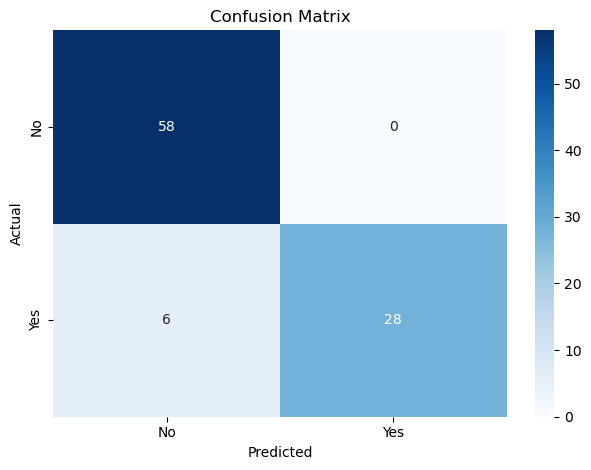

In [73]:
# CONFUSION MATRIX PLOT

plt.figure()
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No','Yes'], yticklabels=['No','Yes'])

plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300)
plt.show()

## STEP 7 – FEATURE IMPORTANCE

In [74]:
# Best Decision Tree
best_dt = res_df[res_df['Model'] == 'Decision Tree'] \
    .sort_values('Val AUC', ascending=False) \
    .iloc[0]['Model_obj']

# Feature importance
imp = pd.Series(best_dt.feature_importances_, index=X.columns) \
        .sort_values(ascending=False)

display(imp.head(8))

surface_debris              0.802677
inspection_season_summer    0.083117
infrastructure_age          0.063282
inspection_season_spring    0.026616
asset_density               0.024308
material_flexibility        0.000000
structural_mass_ratio       0.000000
recent_precipitation        0.000000
dtype: float64

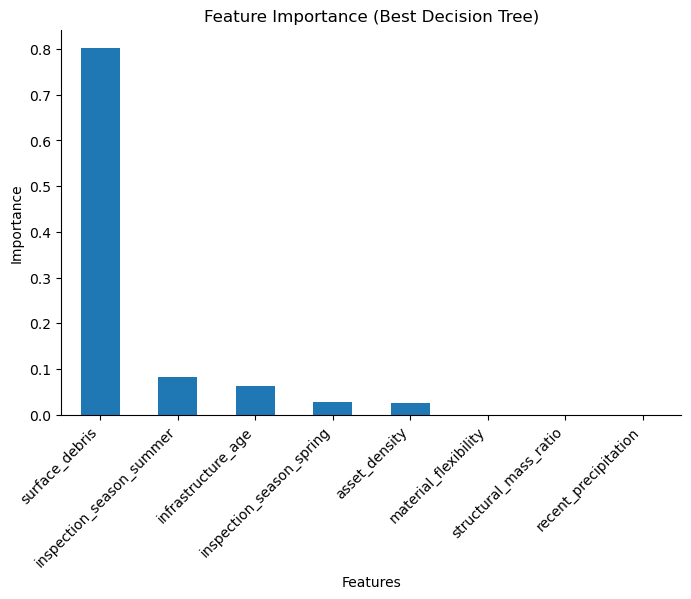

In [75]:
# Select top 8 features and plot
top_features = imp.head(8)

# Plot
plt.figure(figsize=(8,5))

top_features.plot(kind='bar')

# Titles and labels
plt.title('Feature Importance (Best Decision Tree)')
plt.xlabel('Features')
plt.ylabel('Importance')

# Rotate labels for readability
plt.xticks(rotation=45, ha='right')

# Clean style (remove top/right borders)
plt.gca().spines[['top', 'right']].set_visible(False)

# Save for poster
plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')

plt.show()

## STEP 8 – FINAL SUMMARY

In [76]:
print("Best Model:", best['Model'])
print("Hyperparameters:", best['Hyperparameter'])
print(f"AUC: {auc:.3f} | Accuracy: {acc:.3f}")
print(f"Confusion Matrix:\n{cm}")

Best Model: Logistic Regression
Hyperparameters: C=0.01
AUC: 0.992 | Accuracy: 0.935
Confusion Matrix:
[[58  0]
 [ 6 28]]
